# 06 — Análisis focalizado por circuito y Top-97

Flujo **en memoria** (sin guardar CSVs intermedios):

1. Cargar el dataset filtrado al circuito y período.
2. Configurar Kernel SHAP bajo demanda para el modelo TabNet.
3. Aplicar tres escenarios Top-97:
   - Top-97 por `UITI_VANO_PROM` en período completo.
   - Top-97 por frecuencia (`N_APARICIONES`) en período completo.
   - Top-97 por `UITI_VANO_PROM` sobre las fechas de interés concatenadas.
4. Para cada escenario: gráfico de barras de variables y radar por modos.

Las funciones de interpretación viven en `chec_impacto.interpretability.tabnet`.


In [1]:
import io
import os
import subprocess
import sys
import warnings
from contextlib import redirect_stdout
from pathlib import Path

import numpy as np
import pandas as pd

REPO_URL  = "https://github.com/Daprosero/chec_impacto.git"
REPO_NAME = "chec_impacto"

cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "chec_impacto").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    working_root = Path("/kaggle/working") if Path("/kaggle/working").exists() else cwd
    clone_dir = working_root / REPO_NAME
    if not clone_dir.exists():
        subprocess.run(["git", "clone", REPO_URL, str(clone_dir)], check=True)
    PROJECT_ROOT = clone_dir.resolve()

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
os.chdir(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data"
print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter


## Parámetros

In [2]:
CIRCUITO_INTERES         = "DON23L13"
FECHA_INICIO             = "2025-11-01 00:00:01"
FECHA_FIN                = "2026-04-30 21:53:40"
FECHAS_INTERES           = ["2025-11-16", "2025-12-01", "2026-02-02", "2026-03-02", "2026-05-15"]

TOP_N_VANOS              = 97
TOP_K_VARS               = 20
SHAP_BACKGROUND_SIZE     = 40
SHAP_NSAMPLES            = 80
SHAP_BATCH_SIZE          = 64
SHAP_RANDOM_STATE        = 42
FILTRO_UITI_MAX          = 1000
VENTANA_CLIMATICA_HORAS  = 12

DATASET_PATH             = DATA_DIR / "Indicadores_vano_v3.csv"
VARIABLES_SELECCION_PATH = DATA_DIR / "Variables_seleccion.xlsx"
MODEL_PATH               = DATA_DIR / "models" / "best_tabnet_classifier_model.zip"

for _p in [DATASET_PATH, VARIABLES_SELECCION_PATH, MODEL_PATH]:
    if not _p.exists():
        raise FileNotFoundError(f"No encontrado: {_p}")


## 1. Carga y filtrado

Se procesa el dataset completo, se aplica el filtro de circuito + período y se trabaja **solo con esas filas** en adelante.

In [3]:
from chec_impacto.data import procesar_dataset_completo

with redirect_stdout(io.StringIO()):
    datos = procesar_dataset_completo(
        path_clima=DATASET_PATH,
        path_variables_seleccion=VARIABLES_SELECCION_PATH,
        use_sampling=False,
        min_samples_per_codigo=5,
        target="UITI_VANO",
        filtro_uiti_max=FILTRO_UITI_MAX,
        ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
    )

X_full    = np.asarray(datos["X"], dtype=np.float64)
features  = list(datos["features"])
base_full = datos["df_original_copy"].copy().reset_index(drop=True)

fechas_col = pd.to_datetime(base_full["FECHA"], errors="coerce")
mascara = (
    base_full["CIRCUITO"].astype(str).str.strip().eq(CIRCUITO_INTERES)
    & fechas_col.ge(pd.Timestamp(FECHA_INICIO))
    & fechas_col.le(pd.Timestamp(FECHA_FIN))
)
if not mascara.any():
    raise ValueError(
        f"Sin datos para {CIRCUITO_INTERES} entre {FECHA_INICIO} y {FECHA_FIN}."
    )

# X e índices filtrados — referencia 0..N-1 en adelante
X    = X_full[mascara.to_numpy()]                         # (N, n_features)
base = base_full[mascara].copy().reset_index(drop=True)   # índice 0..N-1
base["_FECHA_DIA"] = fechas_col[mascara].dt.strftime("%Y-%m-%d").values

print(f"Circuito     : {CIRCUITO_INTERES}")
print(f"Período      : {FECHA_INICIO}  →  {FECHA_FIN}")
print(f"Eventos      : {len(X):,}")
print(f"Vanos únicos : {base['FID_VANO'].nunique():,}")
print(f"Features     : {len(features)}")

Circuito     : DON23L13
Período      : 2025-11-01 00:00:01  →  2026-04-30 21:53:40
Eventos      : 9,402
Vanos únicos : 845
Features     : 83


## 2. Modelo TabNet

In [4]:
from chec_impacto.models import cargar_modelo_tabnet

with warnings.catch_warnings(), redirect_stdout(io.StringIO()):
    warnings.simplefilter("ignore")
    modelo = cargar_modelo_tabnet("clasificacion", MODEL_PATH)

print(f"Modelo: {type(modelo).__name__}")

Modelo: CustomTabNetClassifier


## 3. Kernel SHAP — configuración bajo demanda

Kernel SHAP se configura sobre la probabilidad positiva del modelo TabNet. Las
atribuciones se calculan **solo para los eventos que entren en cada escenario**
(Top-97 por UITI, Top-97 por frecuencia y Top-97 en fechas de interés). Para el
ranking por fila se usa `abs(SHAP)` y se guarda internamente en `_TOP_VARS`.


In [5]:
from chec_impacto.interpretability.tabnet import KernelShapTopVarsExtractor

shap_extractor = KernelShapTopVarsExtractor(
    model=modelo,
    X=X,
    features=features,
    top_k=TOP_K_VARS,
    background_size=SHAP_BACKGROUND_SIZE,
    nsamples=SHAP_NSAMPLES,
    batch_size=SHAP_BATCH_SIZE,
    random_state=SHAP_RANDOM_STATE,
)
print(
    f"Kernel SHAP configurado | fondo={shap_extractor.n_background} "
    f"| nsamples={SHAP_NSAMPLES} | batch={SHAP_BATCH_SIZE}"
)


Kernel SHAP configurado | fondo=40 | nsamples=80 | batch=64


## 4. Agregación base por vano

La agregación por vano se importa desde `chec_impacto.interpretability.tabnet`.
Cuando un dataframe ya tiene `_TOP_VARS`, la misma función puede adjuntar
`RELEVANCIA_VARS` por regla de Borda.


In [6]:
from chec_impacto.interpretability.tabnet import agrupar_por_vano

print("Funciones de agregación importadas.")


Funciones de agregación importadas.


## 5. Top-97 y gráficos por escenario

Los tres escenarios usan la misma metodología de agregación por vano, Kernel SHAP
como fuente de atribución, Borda ponderado por `abs(SHAP)`, y normalización min-max
0-1 justo antes de graficar. Cada escenario produce únicamente barras y radar.


In [7]:
# Tabla base por vano para el período completo.
tabla_periodo = agrupar_por_vano(base)

n_top = min(TOP_N_VANOS, len(tabla_periodo))
print(f"Top-N configurado : {TOP_N_VANOS}")
print(f"Top-N efectivo    : {n_top}")
print(f"Vanos período     : {len(tabla_periodo)}")


Top-N configurado : 97
Top-N efectivo    : 97
Vanos período     : 845


## 6. Configuración común de modos y gráficos

La construcción de modos y la generación de barras/radar se importan desde
`chec_impacto.interpretability.tabnet`.


In [8]:
from chec_impacto.interpretability.tabnet import construir_modos_chec, graficar_barras_y_radar

MODOS = construir_modos_chec(features, VARIABLES_SELECCION_PATH)
print(f"Modos configurados: {len(MODOS)}")


Modos configurados: 6


## 7. Top-97 por UITI_VANO — período completo


Top-97 por UITI_VANO — período completo | eventos: 359 | vanos: 97


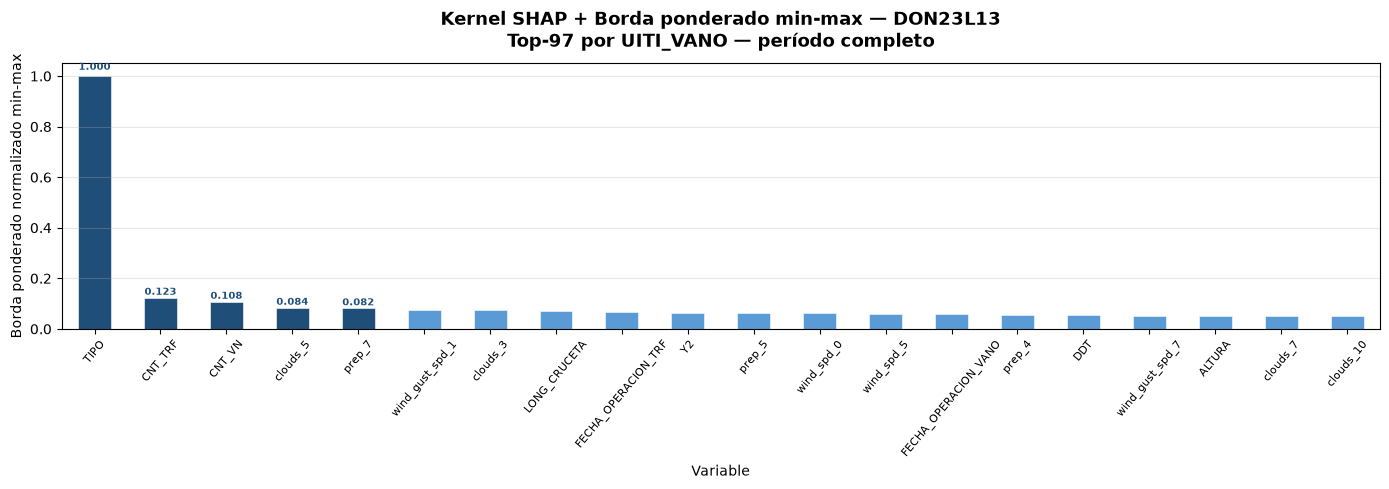

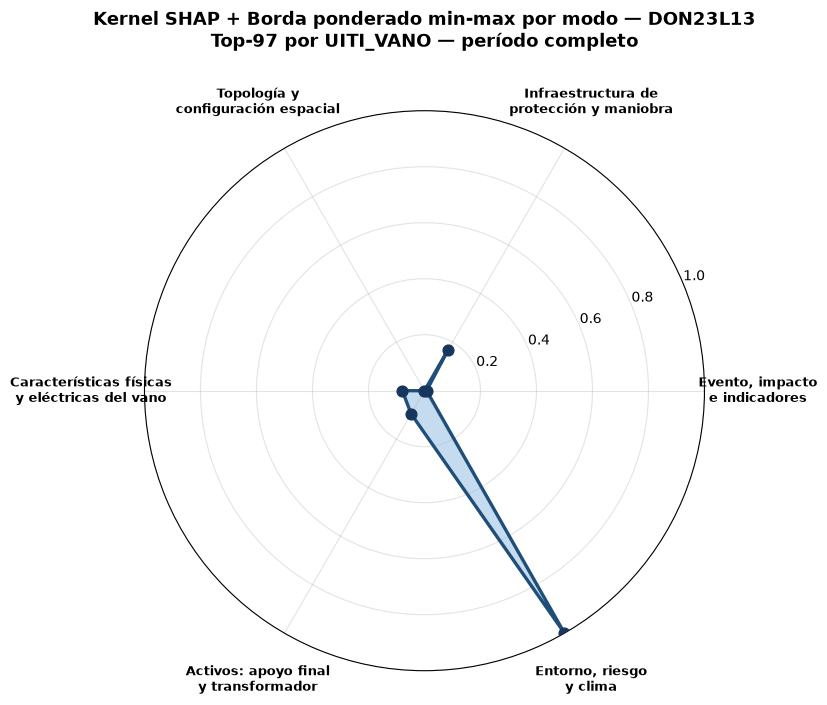

{'eventos':       CIRCUITO    FID_SW COD_EQ_PROTEGE  FID_VANO  T_USUS_EQ_PROT   LVSW  \
 41    DON23L13  20477790         L12923  20475385              52  0.196   
 42    DON23L13  20477790         L12923  20475828              52  0.399   
 43    DON23L13  20477790         L12923  20476148              52  0.527   
 64    DON23L13  20477852         L12556  20475435              77  4.669   
 65    DON23L13  20477852         L12556  20475435              77  4.669   
 ...        ...       ...            ...       ...             ...    ...   
 9037  DON23L13  31433833         L12185  20475974              57  5.443   
 9038  DON23L13  31433833         L12185  20475974              57  5.443   
 9039  DON23L13  31433833         L12185  20475974              57  5.443   
 9040  DON23L13  31433833         L12185  20475974              57  5.443   
 9041  DON23L13  31433833         L12185  20475974              57  5.443   
 
       CNT_VN  CNT_VN_SW               FECHA  DURACION  ...  cl

In [9]:
tabla_top_uiti = (
    tabla_periodo
    .sort_values("UITI_VANO_PROM", ascending=False, kind="stable")
    .head(n_top)
    .reset_index(drop=True)
)
ids_top_uiti = tabla_top_uiti["FID_VANO"].tolist()
base_top_uiti = base[base["FID_VANO"].isin(ids_top_uiti)].copy()

graficar_barras_y_radar(
    base_top_uiti,
    f"Top-{n_top} por UITI_VANO — período completo",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
)


## 8. Top-97 por frecuencia — período completo


Top-97 por frecuencia — período completo | eventos: 4,410 | vanos: 97


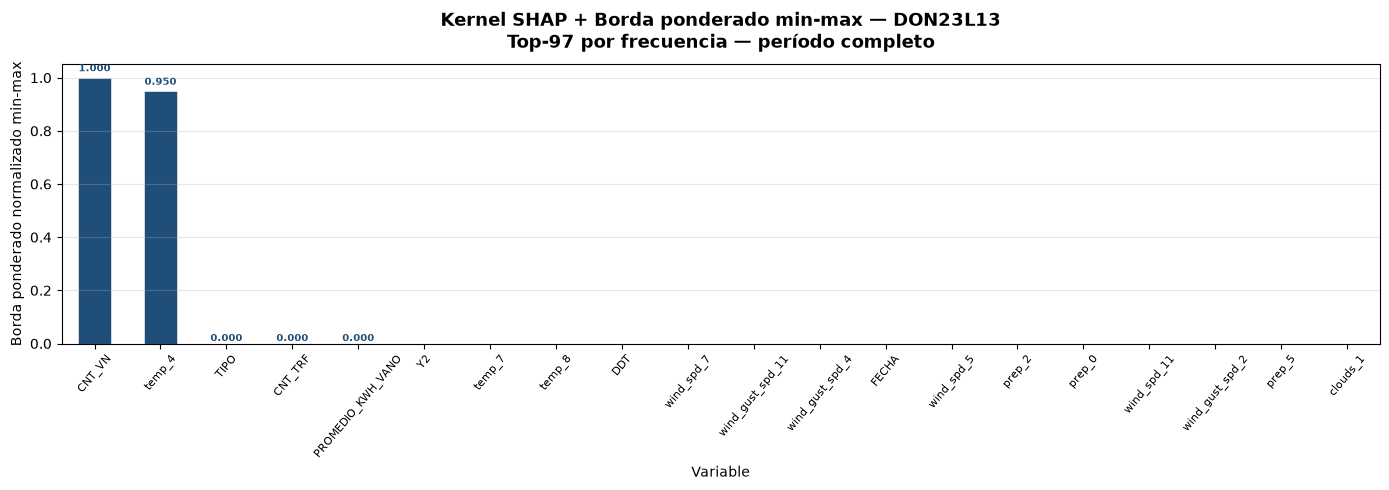

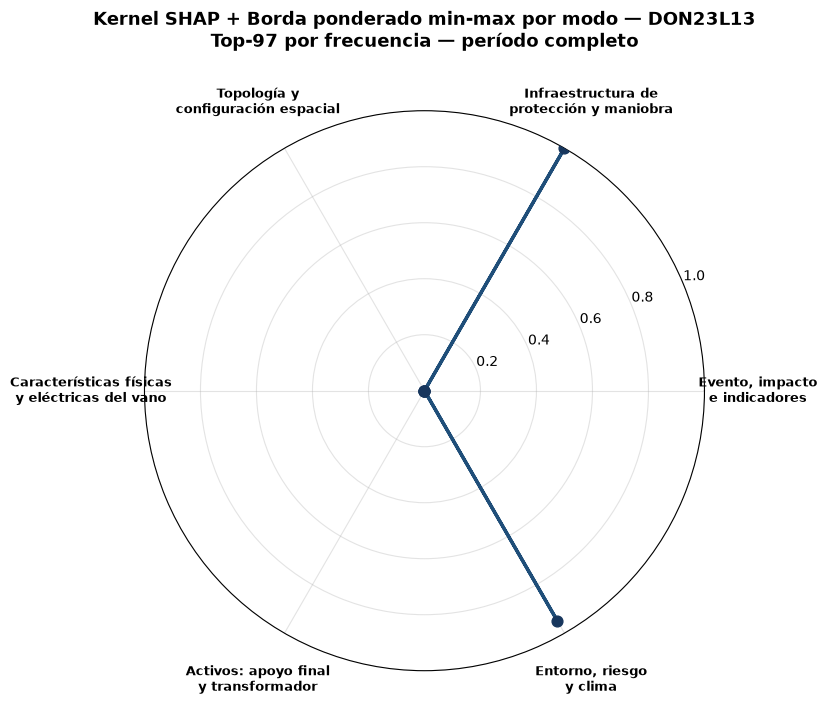

{'eventos':       CIRCUITO     FID_SW COD_EQ_PROTEGE   FID_VANO  T_USUS_EQ_PROT   LVSW  \
 498   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 499   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 500   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 501   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 502   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 ...        ...        ...            ...        ...             ...    ...   
 7604  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7605  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7606  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7607  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7608  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 
       CNT_VN  CNT_VN_SW               

In [10]:
tabla_top_frecuencia = (
    tabla_periodo
    .sort_values(["N_APARICIONES", "UITI_VANO_PROM"], ascending=[False, False], kind="stable")
    .head(n_top)
    .reset_index(drop=True)
)
ids_top_frecuencia = tabla_top_frecuencia["FID_VANO"].tolist()
base_top_frecuencia = base[base["FID_VANO"].isin(ids_top_frecuencia)].copy()

graficar_barras_y_radar(
    base_top_frecuencia,
    f"Top-{n_top} por frecuencia — período completo",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
)


## 9. Top-97 por UITI_VANO — fechas de interés concatenadas


Top-97 por UITI_VANO — fechas de interés concatenadas | eventos: 536 | vanos: 97


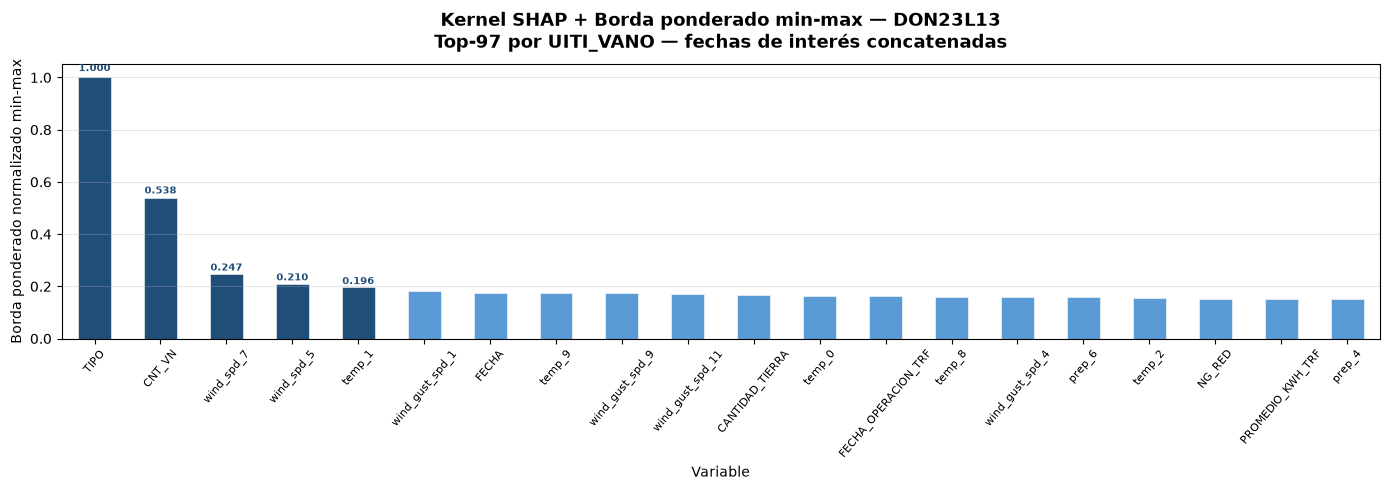

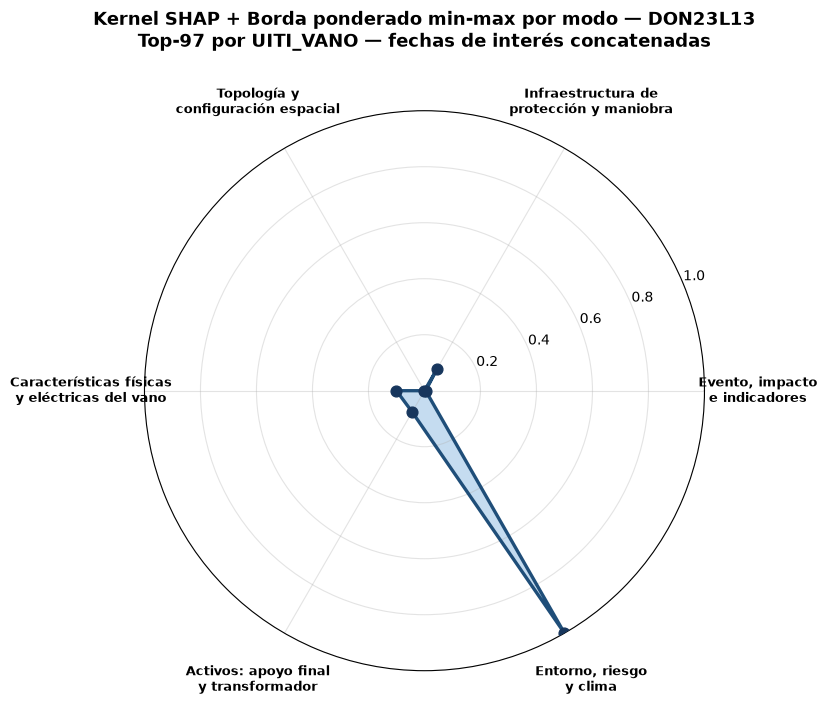

{'eventos':       CIRCUITO    FID_SW COD_EQ_PROTEGE  FID_VANO  T_USUS_EQ_PROT   LVSW  \
 1672  DON23L13  20477897       2DN13R01  20475460             106  2.952   
 1673  DON23L13  20477897       2DN13R01  20475460             106  2.952   
 1674  DON23L13  20477897       2DN13R01  20475460             106  2.952   
 1675  DON23L13  20477897       2DN13R01  20475460             106  2.952   
 1676  DON23L13  20477897       2DN13R01  20475460             106  2.952   
 ...        ...       ...            ...       ...             ...    ...   
 8475  DON23L13  43248281         L12847  20476317              88  4.792   
 8476  DON23L13  43248281         L12847  20476317              88  4.792   
 8489  DON23L13  43248281         L12847  20476378              88  2.552   
 8490  DON23L13  43248281         L12847  20476378              88  2.552   
 8491  DON23L13  43248281         L12847  20476378              88  2.552   
 
       CNT_VN  CNT_VN_SW               FECHA  DURACION  ...  cl

In [11]:
base_fechas = base[base["_FECHA_DIA"].isin(FECHAS_INTERES)].copy()
if base_fechas.empty:
    raise ValueError("No hay eventos para las FECHAS_INTERES configuradas.")

tabla_fechas = agrupar_por_vano(base_fechas)
n_top_fechas = min(TOP_N_VANOS, len(tabla_fechas))
tabla_top_fechas = (
    tabla_fechas
    .sort_values("UITI_VANO_PROM", ascending=False, kind="stable")
    .head(n_top_fechas)
    .reset_index(drop=True)
)
ids_top_fechas = tabla_top_fechas["FID_VANO"].tolist()
base_top_fechas = base_fechas[base_fechas["FID_VANO"].isin(ids_top_fechas)].copy()

graficar_barras_y_radar(
    base_top_fechas,
    f"Top-{n_top_fechas} por UITI_VANO — fechas de interés concatenadas",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
)
